In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Chapter 2

Here are some notes on things I've learnt along the way. Will do the same for other chapters.

A future (or futures contract) is a standardized agreement to buy or sell an asset at a specific price on a specific future date.
It's a type of derivative, meaning its value is based on the price of something else — like:
- Bitcoin
- Oil
- S&P 500
- Wheat
- Interest rates

Let’s say today’s BTC spot price is $60,000.
You look at a futures contract that expires in 3 months:
- It trades at $61,000
- That $1,000 difference is the premium — people are willing to pay more to lock in future exposure.
- This is called contango (when futures > spot). The opposite — backwardation — happens when futures < spot.

When rolling from an old futures contract to a new one, the prices often jump due to differences in expiry, carry, or liquidity — creating artificial gaps in your backtest.

If you're arbitraging, hedging, or doing roll-adjusted modeling, you’ll want to stream both:
- Spot: Reflects current BTC market value.
- Futures: Reflect market expectations + basis (premium/discount due to interest rates, funding, etc.).

Hedging is like buying insurance. You're trying to protect yourself against price movements you don’t want.

E.g. you're a miner and will get 1 BTC next month. You're afraid the BTC price might drop.
- So you sell a BTC future now, locking in today’s price.
- If BTC drops -> your future position makes money.
- If BTC rises -> you earn less, but you’re protected.

You’ve reduced your risk. You traded upside for certainty.

Arbitrage is exploiting price differences across markets for the same asset.
E.g. spot vs Futures arbitrage:
- Spot BTC is $60,000
- BTC Future (next month) is $60,500
- You:
    - Buy spot BTC
    - Sell the future
- When the future expires:
    - They converge in price
    - You collect the $500 premium (minus costs)

This works only if execution is fast and slippage/funding is low.

The ETF trick uses both spot prices (e.g., BTC/USDT from Binance) and futures prices (e.g., perpetual or quarterly BTC futures from CME/Binance) to create a synthetic, smoother price series that is less noisy, less manipulable, and more indicative of the true market value.

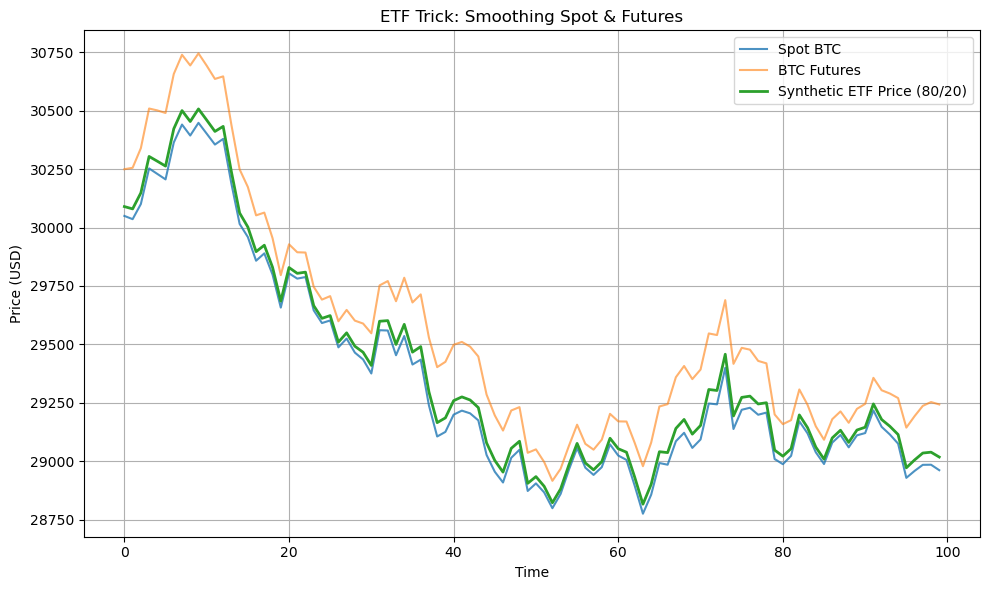

In [2]:
# Simulated time
np.random.seed(42)
t = np.arange(100)

# Simulated spot price: drifting up with noise
spot = 30000 + np.cumsum(np.random.randn(len(t)) * 100)

# Simulated futures price: slightly above spot due to premium
futures = spot + 200 + np.sin(t / 5.0) * 100  # basis/premium oscillates

# ETF Trick: smooth combination (e.g. 80% spot, 20% futures)
alpha = 0.8
etf_price = alpha * spot + (1 - alpha) * futures

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(t, spot, label="Spot BTC", alpha=0.8)
plt.plot(t, futures, label="BTC Futures", alpha=0.6)
plt.plot(t, etf_price, label="Synthetic ETF Price (80/20)", linewidth=2)
plt.title("ETF Trick: Smoothing Spot & Futures")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


There is more to this but it is not relevant to perpetual data.